**Fundamentos de Data Science**

**Analizando la Satisfacción de Clientes en la Industria Hotelera**

Tu tarea es limpiar y explorar un dataset que contiene información sobre la satisfacción de los clientes en la industria hotelera. Este análisis es crucial para los ejecutivos de la empresa que buscan entender mejor las opiniones y experiencias de sus clientes para mejorar los servicios ofrecidos.


**1. Limpieza de datos con Python:**

1.1. Detección y eliminación de valores duplicados: Asegúrate de que cada registro en el dataset sea único.

1.2. Verificación y ajuste de tipos de datos: Asegúrate de que todas las columnas coincidan con los tipos de datos indicados en el diccionario de datos.

1.3. Consistencia en valores categóricos: Identifica y corrige cualquier inconsistencia en los valores categóricos (por ejemplo, ‘yes’, ‘Yes’, ‘YES’).

1.4. Manejo de valores faltantes: Identifica y maneja cualquier valor faltante en el dataset. Rellena los valores faltantes con un marcador adecuado para el tipo de dato.

1.5. Detección de datos anómalos: Identifica y corrige cualquier punto de dato inapropiado o inusual (por ejemplo, una estancia de 1000 noches).


In [173]:
# Importamos pandas para la manipulación y estructuración de los datos.
import pandas as pd

# Importamos numpy para operaciones matemáticas avanzadas si fuesen necesarias.
import numpy as np

# Importamos matplotlib y seaborn para la creación de visualizaciones estadísticas.
import matplotlib.pyplot as plt
import seaborn as sns


In [174]:
# Implementamos control de errores para la carga del archivo.
try:
    df = pd.read_csv("/content/hotel_bookings.csv.zip")
    print("Dataset demanda de reservas de hotel cargado exitosamente.")
except FileNotFoundError:
    print(f"Error crítico: El archivo no se encontró en el directorio.")
    exit()

Dataset demanda de reservas de hotel cargado exitosamente.


In [157]:
# Visualizamos los primeros y ultimos registros para entender la estructura tabular.
print("Primeras filas del DataFrame:")
print(df.head())
print("Últimas filas del DataFrame:")
print(df.tail())

Primeras filas del DataFrame:
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       

In [175]:
# Revisamos los metadatos: cantidad de nulos y tipos de variables originales.
print("\n--- Información Estructural ---")
df.info()


--- Información Estructural ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-nu

In [176]:
# Generar estadísticas descriptivas
print("Estadísticas descriptivas del DataFrame:")
print(df.describe())

Estadísticas descriptivas del DataFrame:
         is_canceled      lead_time  arrival_date_year  \
count  119390.000000  119390.000000      119390.000000   
mean        0.370416     104.011416        2016.156554   
std         0.482918     106.863097           0.707476   
min         0.000000       0.000000        2015.000000   
25%         0.000000      18.000000        2016.000000   
50%         0.000000      69.000000        2016.000000   
75%         1.000000     160.000000        2017.000000   
max         1.000000     737.000000        2017.000000   

       arrival_date_week_number  arrival_date_day_of_month  \
count             119390.000000              119390.000000   
mean                  27.165173                  15.798241   
std                   13.605138                   8.780829   
min                    1.000000                   1.000000   
25%                   16.000000                   8.000000   
50%                   28.000000                  16.000000   
75

In [177]:
# Inspeccionar los tipos de datos de las columnas
print("nTipos de datos de las columnas:")
print(df.dtypes)

nTipos de datos de las columnas:
hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
a

In [178]:
# Obtenemos un conteo inicial de valores faltantes por columna.
print("\n--- Conteo de Valores Nulos ---")
print(df.isnull().sum())


--- Conteo de Valores Nulos ---
hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                   

In [179]:
# 1.1. Detección y eliminación de valores duplicados: Asegúrate de que cada registro en el dataset sea único.
cantidad_duplicados = df.duplicated().sum()
print(f"Duplicados encontrados: {cantidad_duplicados}")

# Eliminamos duplicados directamente sobre el DataFrame.
initial_rows = len(df)
df.drop_duplicates(inplace=True)

print(f"Se eliminaron {initial_rows - len(df)} filas duplicadas. Filas restantes: {len(df)}")

Duplicados encontrados: 31994
Se eliminaron 31994 filas duplicadas. Filas restantes: 87396


In [180]:
# 1.2. Verificación y ajuste de tipos de datos: Asegúrate de que todas las columnas coincidan con los tipos de datos indicados en el diccionario de datos.

print("Tipos de datos actuales")
print(df.dtypes)

# Convertir columnas categóricas a string
columnas_texto = [
    'hotel',
    'arrival_date_month',
    'meal',
    'country',
    'market_segment',
    'distribution_channel',
    'reserved_room_type',
    'assigned_room_type',
    'deposit_type',
    'customer_type',
    'reservation_status'
]
for col in columnas_texto:

    df[col] = df[col].astype('string')

# Convertir columnas enteras
columnas_int = [
    'is_canceled',
    'lead_time',
    'arrival_date_year',
    'arrival_date_week_number',
    'arrival_date_day_of_month',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'babies',
    'is_repeated_guest',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'required_car_parking_spaces',
    'total_of_special_requests'
]
for col in columnas_int:

    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    ).astype('Int64')

# Convertir columnas float
columnas_float = [
    'children',
    'adr'
]
for col in columnas_float:

    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )

# Convertir fecha
df['reservation_status_date'] = pd.to_datetime(
    df['reservation_status_date'],
    errors='coerce'
)
print(df.dtypes)

Tipos de datos actuales
hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent     

In [166]:
# 1.3. Consistencia en valores categóricos: Identifica y corrige cualquier inconsistencia en los valores categóricos (por ejemplo, ‘yes’, ‘Yes’, ‘YES’).
# Revisar valores únicos
columnas_categoricas = [
    'hotel',
    'meal',
    'country',
    'market_segment',
    'distribution_channel',
    'reserved_room_type',
    'assigned_room_type',
    'deposit_type',
    'customer_type',
    'reservation_status'
]

for col in columnas_categoricas:

    print(f"\nValores únicos en {col}:")

    print(df[col].unique())


Valores únicos en hotel:
<StringArray>
['Resort Hotel', 'City Hotel']
Length: 2, dtype: string

Valores únicos en meal:
<StringArray>
['BB', 'FB', 'HB', 'SC', 'Undefined']
Length: 5, dtype: string

Valores únicos en country:
<StringArray>
['PRT', 'GBR', 'USA', 'ESP', 'IRL', 'FRA',  <NA>, 'ROU', 'NOR', 'OMN',
 ...
 'ATA', 'GTM', 'ASM', 'MRT', 'NCL', 'KIR', 'SDN', 'ATF', 'SLE', 'LAO']
Length: 178, dtype: string

Valores únicos en market_segment:
<StringArray>
[       'Direct',     'Corporate',     'Online TA', 'Offline TA/TO',
 'Complementary',        'Groups',     'Undefined',      'Aviation']
Length: 8, dtype: string

Valores únicos en distribution_channel:
<StringArray>
['Direct', 'Corporate', 'TA/TO', 'Undefined', 'GDS']
Length: 5, dtype: string

Valores únicos en reserved_room_type:
<StringArray>
['C', 'A', 'D', 'E', 'G', 'F', 'H', 'L', 'P', 'B']
Length: 10, dtype: string

Valores únicos en assigned_room_type:
<StringArray>
['C', 'A', 'D', 'E', 'G', 'F', 'I', 'B', 'H', 'P', 'L', 'K

In [167]:
# Consistencia en valores categóricos
columnas_categoricas = [
    'hotel',
    'meal',
    'country',
    'market_segment',
    'distribution_channel',
    'reserved_room_type',
    'assigned_room_type',
    'deposit_type',
    'customer_type',
    'reservation_status'
]
for col in columnas_categoricas:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.title()
    )

for col in columnas_categoricas:

    print(f"\nValores corregidos en {col}:")

    print(df[col].unique())


Valores corregidos en hotel:
['Resort Hotel' 'City Hotel']

Valores corregidos en meal:
['Bb' 'Fb' 'Hb' 'Sc' 'Undefined']

Valores corregidos en country:
['Prt' 'Gbr' 'Usa' 'Esp' 'Irl' 'Fra' '<Na>' 'Rou' 'Nor' 'Omn' 'Arg' 'Pol'
 'Deu' 'Bel' 'Che' 'Cn' 'Grc' 'Ita' 'Nld' 'Dnk' 'Rus' 'Swe' 'Aus' 'Est'
 'Cze' 'Bra' 'Fin' 'Moz' 'Bwa' 'Lux' 'Svn' 'Alb' 'Ind' 'Chn' 'Mex' 'Mar'
 'Ukr' 'Smr' 'Lva' 'Pri' 'Srb' 'Chl' 'Aut' 'Blr' 'Ltu' 'Tur' 'Zaf' 'Ago'
 'Isr' 'Cym' 'Zmb' 'Cpv' 'Zwe' 'Dza' 'Kor' 'Cri' 'Hun' 'Are' 'Tun' 'Jam'
 'Hrv' 'Hkg' 'Irn' 'Geo' 'And' 'Gib' 'Ury' 'Jey' 'Caf' 'Cyp' 'Col' 'Ggy'
 'Kwt' 'Nga' 'Mdv' 'Ven' 'Svk' 'Fji' 'Kaz' 'Pak' 'Idn' 'Lbn' 'Phl' 'Sen'
 'Syc' 'Aze' 'Bhr' 'Nzl' 'Tha' 'Dom' 'Mkd' 'Mys' 'Arm' 'Jpn' 'Lka' 'Cub'
 'Cmr' 'Bih' 'Mus' 'Com' 'Sur' 'Uga' 'Bgr' 'Civ' 'Jor' 'Syr' 'Sgp' 'Bdi'
 'Sau' 'Vnm' 'Plw' 'Qat' 'Egy' 'Per' 'Mlt' 'Mwi' 'Ecu' 'Mdg' 'Isl' 'Uzb'
 'Npl' 'Bhs' 'Mac' 'Tgo' 'Twn' 'Dji' 'Stp' 'Kna' 'Eth' 'Irq' 'Hnd' 'Rwa'
 'Khm' 'Mco' 'Bgd' 'Imn' 'Tjk' 'Nic' 'Ben'

In [168]:
# 1.4. Manejo de valores faltantes: Identifica y maneja cualquier valor faltante en el dataset. Rellena los valores faltantes con un marcador adecuado para el tipo de dato.
# Calcular la cantidad de valores nulos por cada columna en el DataFrame df
nulos = df.isnull().sum()
# Filtrar solo las columnas que tienen al menos un valor nulo
# y ordenarlas de mayor a menor cantidad de nulos
nulos = nulos[nulos > 0].sort_values(ascending=False)
# Imprimir la cantidad de valores nulos por columna (solo las que tienen nulos)
print(nulos)

company     82137
agent       12193
children        4
dtype: int64


In [169]:
# Rellenar valores nulos usando
# Manejo de valores faltantes

df['company'] = df['company'].fillna(0)
df['agent'] = df['agent'].fillna(0)

# Reemplazar nulos en children
df['children'] = df['children'].fillna(
    df['children'].median()
)

# Verificar cambios
print(df.isnull().sum())

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

In [185]:
# 1.5. Detección de datos anómalos: Identifica y corrige cualquier punto de dato inapropiado o inusual (por ejemplo, una estancia de 1000 noches).
# Crear columna de total de noches
df['total_nights'] = (
    df['stays_in_weekend_nights'] +
    df['stays_in_week_nights']
)
# Revisar estadías muy largas
print(
    df[df['total_nights'] > 30]
)

               hotel  is_canceled  lead_time  arrival_date_year  \
1655    Resort Hotel            0         30               2015   
3820    Resort Hotel            1        122               2016   
3850    Resort Hotel            0        214               2016   
5344    Resort Hotel            1         13               2016   
9839    Resort Hotel            1        322               2017   
14037   Resort Hotel            0        113               2015   
14038   Resort Hotel            0        126               2016   
20835   Resort Hotel            0         92               2016   
31404   Resort Hotel            0        148               2016   
32589   Resort Hotel            0          1               2017   
32946   Resort Hotel            0        140               2017   
33234   Resort Hotel            0        192               2017   
33620   Resort Hotel            0         88               2017   
33924   Resort Hotel            0         71               201

In [191]:
# Cantidad de estadías largas
print(
    f"Reservas con más de 30 noches: {len(df[df['total_nights'] > 30])}"
)

Reservas con más de 30 noches: 23


Durante el proceso de limpieza de datos se verificó que el dataset contenía 31.994 registros duplicados, los cuales fueron eliminados, quedando un total de 87.396 filas.

Además, se revisaron y ajustaron los tipos de datos para mantener coherencia entre variables numéricas, categóricas y de fecha. También se estandarizaron los valores categóricos para evitar inconsistencias de formato, como diferencias entre mayúsculas, minúsculas y espacios innecesarios.

Con respecto a los valores nulos, se identificaron 82.137 registros faltantes en la columna company, 12.193 en agent y 4 en children. En el caso de company y agent, se consideró que estas reservas no fueron realizadas mediante compañías o agentes, por lo que los valores faltantes fueron reemplazados por 0 con el fin de conservar la mayor cantidad de información posible en el dataset y los datos de children se mantuvieron reemplazando los nulos con la mediana.

Finalmente, para la detección de datos anómalos, se creó una nueva columna con el total de noches de hospedaje y se analizaron las reservas que superaban los 30 días de estancia. Se encontraron 23 casos, los cuales fueron considerados válidos, ya que podrían corresponder a hospedajes prolongados reales.





**2. Exploración de datos con Python:**

2.1. Visualizaciones exploratorias univariadas: Crea dos tipos diferentes de visualizaciones univariadas. Cada visualización debe incluir una breve interpretación dentro del archivo de código.

2.2. Visualizaciones exploratorias multivariadas: Crea dos tipos diferentes de visualizaciones multivariadas. Cada visualización debe incluir una breve interpretación dentro del archivo de código.

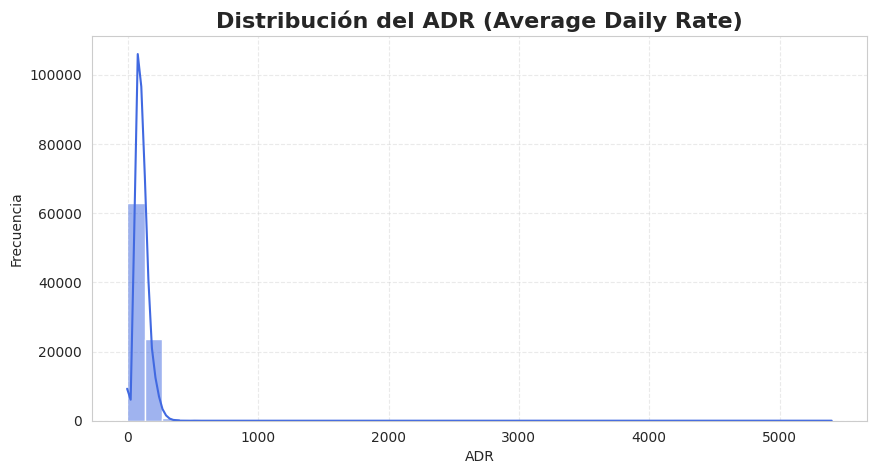

La mayoría de las reservas presentan un ADR bajo o moderado, mientras que existen pocos casos con precios considerablemente
más altos, lo que evidencia una distribución asimétrica.


In [190]:
# 2.1. Visualizaciones exploratorias univariadas: Crea dos tipos diferentes de visualizaciones univariadas.
# Cada visualización debe incluir una breve interpretación dentro del archivo de código.
# Distribución de ADR (precio promedio diario)
plt.figure(figsize=(10,5))
sns.histplot(
    df['adr'],
    bins=40,
    kde=True,
    color='royalblue'
)
plt.title(
    'Distribución del ADR (Average Daily Rate)',
    fontsize=16,
    fontweight='bold'
)
plt.xlabel('ADR')
plt.ylabel('Frecuencia')
plt.grid(
    linestyle='--',
    alpha=0.4
)
plt.show()
print('La mayoría de las reservas presentan un ADR bajo o moderado, mientras que existen pocos casos con precios considerablemente')
print('más altos, lo que evidencia una distribución asimétrica.')

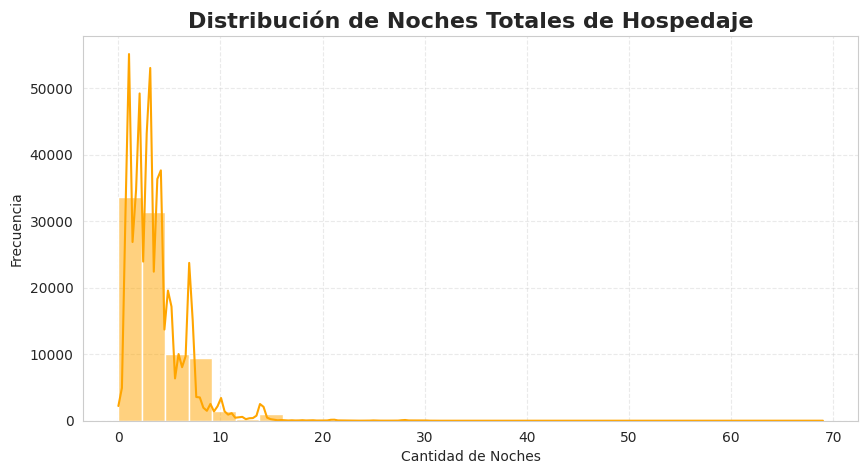

La mayoría de los huéspedes realiza estadías cortas,
mientras que las reservas de larga duración son menos frecuentes.


In [189]:
# Distribución de estadías totales
plt.figure(figsize=(10,5))
sns.histplot(
    df['total_nights'],
    bins=30,
    kde=True,
    color='orange'
)
plt.title(
    'Distribución de Noches Totales de Hospedaje',
    fontsize=16,
    fontweight='bold'
)
plt.xlabel('Cantidad de Noches')
plt.ylabel('Frecuencia')

plt.grid(
    linestyle='--',
    alpha=0.4
)
plt.show()
print('La mayoría de los huéspedes realiza estadías cortas,')
print('mientras que las reservas de larga duración son menos frecuentes.')

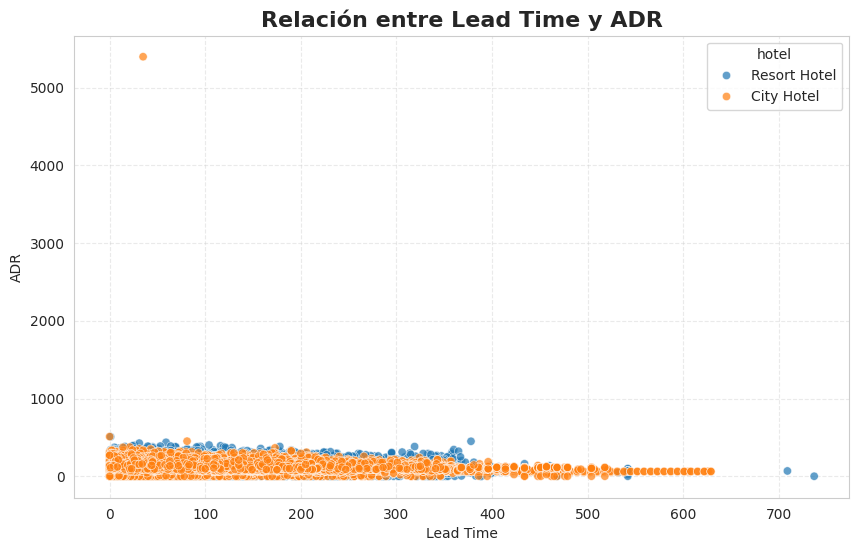

El gráfico muestra la relación entre la anticipación de la reserva y el precio promedio diario. También permite identificar diferencias
entre tipos de hotel y posibles valores atípicos.


In [198]:
# 2.2. Visualizaciones exploratorias multivariadas: Crea dos tipos diferentes de visualizaciones multivariadas.
# Cada visualización debe incluir una breve interpretación dentro del archivo de código.
# 2.2.1. Relación entre Lead Time y ADR
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='lead_time',
    y='adr',
    hue='hotel',
    alpha=0.7
)
plt.title(
    'Relación entre Lead Time y ADR',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Lead Time')
plt.ylabel('ADR')

plt.grid(
    linestyle='--',
    alpha=0.4
)
plt.show()
print('El gráfico muestra la relación entre la anticipación de la reserva y el precio promedio diario. También permite identificar diferencias')
print('entre tipos de hotel y posibles valores atípicos.')

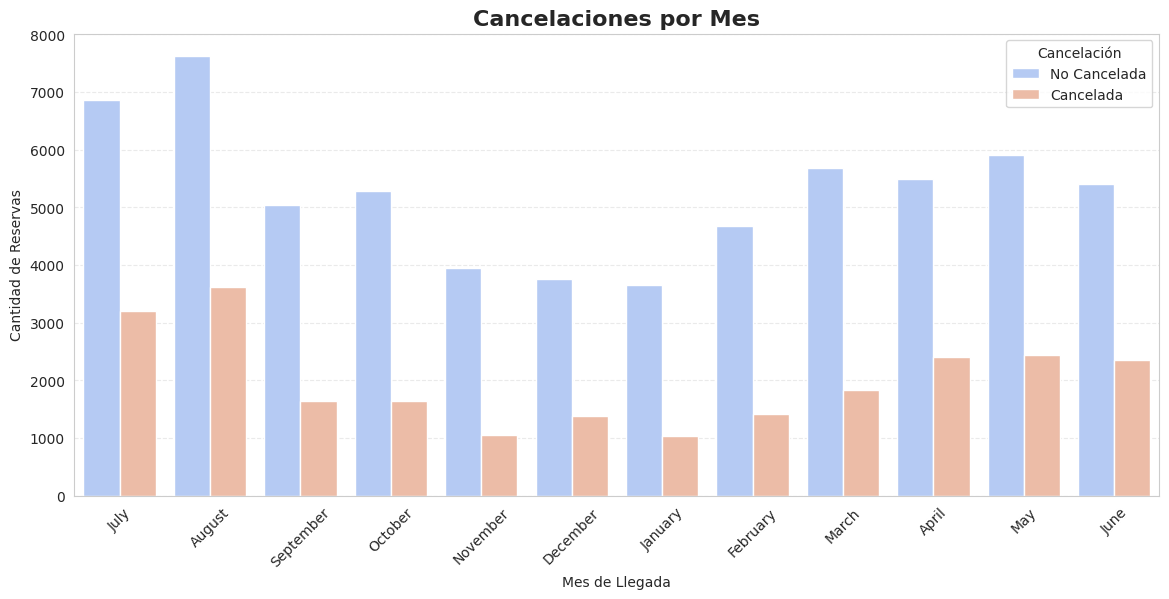

El gráfico permite identificar en qué meses existe una mayor cantidad de cancelaciones y comparar el comportamiento de las reservas
a lo largo del año.


In [200]:
# 2.2.2. Cancelaciones por mes y tipo de hotel
plt.figure(figsize=(14,6))
sns.countplot(
    data=df,
    x='arrival_date_month',
    hue='is_canceled',
    palette='coolwarm'
)
plt.title(
    'Cancelaciones por Mes',
    fontsize=16,
    fontweight='bold'
)
plt.xlabel('Mes de Llegada')
plt.ylabel('Cantidad de Reservas')
plt.xticks(rotation=45)
plt.legend(
    title='Cancelación',
    labels=['No Cancelada', 'Cancelada']
)
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)
plt.show()
print('El gráfico permite identificar en qué meses existe una mayor cantidad de cancelaciones y comparar el comportamiento de las reservas')
print('a lo largo del año.')

El dataset de reservas hoteleras revela patrones claros en el comportamiento de los huéspedes. La mayoría de las reservas se concentran en estadías cortas de entre 1 y 7 noches, con tarifas diarias (ADR) moderadas generalmente por debajo de los 500, aunque existen outliers extremos que distorsionan ambas distribuciones y que deberán tratarse antes de cualquier modelado.

En cuanto a la anticipación de reserva, la mayor densidad se agrupa entre 0 y 300 días, siendo el City Hotel el que presenta el outlier más crítico en precio 5.400 ADR, mientras que el Resort Hotel concentra los casos de mayor anticipación 720 días.

Finalmente, el análisis de cancelaciones por mes muestra que julio y agosto son los meses con mayor volumen total de reservas y también con mayor cantidad de cancelaciones, lo que sugiere que la alta demanda estival no garantiza ocupación efectiva. Por el contrario, los meses de invierno (noviembre, diciembre, enero) presentan menor actividad, pero tasas de cancelación proporcionalmente más bajas, indicando reservas más comprometidas.

Nota: se podría tomar como outliers los valores muy altos por noche y las reservas que sean muy anticipación, pero también podrían ser reservas por matrimonio o aniversarios.



**3. Análisis adicional:**

3.1. Estadísticas descriptivas: Proporciona un resumen estadístico del dataset, incluyendo medidas de tendencia central y dispersión para las variables numéricas.

3.2. Identificación de tendencias: Analiza y discute cualquier tendencia notable que observes en los datos, apoyándote en las visualizaciones y estadísticas descriptivas.


In [202]:
# 3.1. Resumen estadístico general
# Variables numéricas del dataset
variables_numericas = [
    'lead_time',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'adr',
    'booking_changes',
    'days_in_waiting_list',
    'required_car_parking_spaces',
    'total_of_special_requests',
    'total_nights'
]
# Resumen estadístico
resumen = df[variables_numericas].describe()
print("Resumen estadístico:")
print(resumen)


Resumen estadístico:
       lead_time  stays_in_weekend_nights  stays_in_week_nights    adults  \
count    87396.0                  87396.0               87396.0   87396.0   
mean   79.891368                 1.005263              2.625395  1.875795   
std    86.052325                 1.031921              2.053584    0.6265   
min          0.0                      0.0                   0.0       0.0   
25%         11.0                      0.0                   1.0       2.0   
50%         49.0                      1.0                   2.0       2.0   
75%        125.0                      2.0                   4.0       2.0   
max        737.0                     19.0                  50.0      55.0   

           children    babies           adr  booking_changes  \
count  87392.000000   87396.0  87396.000000          87396.0   
mean       0.138640  0.010824    106.337246         0.271603   
std        0.455881  0.113597     55.013953         0.727245   
min        0.000000       0.0

3.2. En conjunto, el dataset refleja un perfil de huésped típico correspondiente a parejas sin hijos, que realizan estadías cortas, con tarifas moderadas y un comportamiento de reserva relativamente estándar, aunque existen algunos valores atípicos que podrían requerir tratamiento previo al modelado predictivo.

En cuanto a la anticipación de las reservas (lead_time), la mediana fue de 49 días y la media cercana a 80 días, lo que refleja una alta variabilidad y sugiere que muchos clientes realizan reservas con poca anticipación, mientras otros reservan con varios meses de antelación.

**Nota:** Uso de recursos externos. Durante el desarrollo de este análisis se utilizaron recursos de apoyo como apuntes de clases, trabajos Core, Examen tipo realizado por Profesores, (examen 1, examen 2 y examenes tipos) documentación oficial de Pandas, Matplotlib, Scikit-learn y consultas complementarias en ChatGPT para resolver dudas, depurar errores y mejorar la comprensión del código utilizado.

Referencias:

https://pandas.pydata.org/docs/

https://matplotlib.org/stable/index.html

https://scikit-learn.org/stable/

https://chat.openai.com/

https://seaborn.pydata.org/



